In [1]:
import numpy as np
import socket
import os
from datetime import date, datetime, time, timezone, timedelta
import matplotlib.pyplot as plt

from dateutil.relativedelta import relativedelta

# import cf-units aware xarray. needs to be in this order
from xarray import open_mfdataset, open_dataset
import pint
import xarray as xr
import pint_xarray
import cf_xarray as cfxr # not side-effect free
import cf_xarray.units
xr.set_options(keep_attrs=True)
import xesmf as xe
import xcdat # SO many monkey patches

import xarray_leaflet
from ipyleaflet import Map, basemaps, LayersControl, WidgetControl
from ipywidgets import FloatSlider

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

In [2]:
import os, sys
current_directory = os.getcwd()

# NOTE: this import fucks with your working directory. Use caution.
correct_dir = os.path.abspath('')
from idlpy import * 
# sys.path.append('/usr/local/nv5/idl/lib/bridges')
# sys.path.append('/Applications/NV5/idl91/lib/bridges')
os.chdir(correct_dir)

IDL 9.1.0 (darwin arm64 m64).
(c) 2024, NV5 Geospatial Solutions, Inc.

Want an IDL Workbench alternative? Check out "IDL for VSCode" for a new user experience.
https://marketplace.visualstudio.com/items?itemName=IDL.idl-for-vscode
 


### .sav to .netCDF

In [3]:
earth_radius = 6371.009 # John's Earth radius = 6.371e6
c_molar_mass = 12.011 * cf_xarray.units.units('g / mol')

def seconds_in_month(year, month):
    dt = datetime(year, month, 1, 0, 0, 0)
    next_month_dt = datetime(year, month, 1, 0, 0, 0) + timedelta(days=40)
    next_month_dt = datetime(next_month_dt.year, next_month_dt.month, 1, 0, 0, 0, 0)
    return (next_month_dt.timestamp() - dt.timestamp()) * cf_xarray.units.units('s')

def seconds_in_year(year): # since it changes per year. NOTE: doesn't handle leap seconds correctly (unix just smears them). Probably doesn't matter.
    return (datetime(year+1, 1, 1, 0, 0, 0).timestamp() - datetime(year, 1, 1, 0, 0, 0).timestamp()) * cf_xarray.units.units('s / yr')

def days_in_year(year): # since it changes per year.
    return seconds_in_year(year) / (24 * 3600) * cf_xarray.units.units('day')

In [4]:
# WARNING: just assumes a bunch of stuff about units and format. check them before running.
IDL.restore("./outputs/fluxarr3_2025a.sav")

right_here_right_now = f'Postproccesed on {datetime.now(timezone.utc)} by script {os.getcwd()} on {socket.gethostname()}'

first_day = date(1993,1,15)
lat = np.linspace(-89.5, 89.5, 180)
lon = np.linspace(-179.5, 179.5, 360) 
times = [datetime.combine(first_day + relativedelta(months=month), time.min) for month in range(33 * 12)]

# TODO: there's time in these units somewhere
data = xr.DataArray(IDL.fluxarr3, coords={'lat': lat,'lon': lon,'time': times}, dims=["lat", "lon", "time"], name='fossil_imp_cell', 
                    attrs={'long_name' : 'carbon dioxide as mol carbon emitted into atmosphere per cell per time period'}).pint.quantify('Gg').to_dataset()
data.attrs = data.attrs | {
    'source' : 'Miller FF 2025a, 1993 country bounds. From: CDIAC at AppState 2020; EI Statistical Review of World Energy Data 2024; EDGAR_2024_GHG; USGS MCS Cement 2020, 2021, 2022, 2023, 2024, 2025',
    'title' : 'Miller Fossil Fuel prior estimates for CT',
    'history' : f'Created by ff_country_new2025a.pro April 2025\n{right_here_right_now}',
    'institution': 'NOAA Global Monitoring Laboratory'
}
data = data.cf.add_bounds(['lat', 'lon'])
data = data.bounds.add_time_bounds('freq', 'month')
data['time_bnds'].encoding['units'] = 'days since 1970-01-01'
data['time'].encoding['units'] = 'days since 1970-01-01'

data['fossil_imp_cell'] /= c_molar_mass # to molar value

data['earth_radius'] = earth_radius
data['earth_radius'].attrs['units'] = 'km'
grid_1x1 = xe.util.grid_global(1, 1, cf=True).drop_vars('latitude_longitude')
data['cell_areas'] = xe.util.cell_area(grid_1x1, earth_radius=earth_radius).pint.quantify('km**2') # in km2


data['year_lengths'] =  xr.DataArray([seconds_in_year(t.year).magnitude for t in times], dims=["time"]).pint.quantify('s')
data['month_lengths'] =  xr.DataArray([seconds_in_month(t.year, t.month).magnitude for t in times], dims=["time"]).pint.quantify('s')
data['fossil_imp_area'] = data['fossil_imp_cell'] / data['cell_areas'] / data['year_lengths'] 
data['fossil_imp_area'] = data['fossil_imp_area'].pint.to('mol / m**2 / s') 
data['fossil_imp_area'].attrs['long name'] = 'carbon dioxide as mol carbon emitted into atmosphere per unit area and time'

data.pint.dequantify().to_netcdf('outputs/ash_ff_2025a.nc')
#display([days_in_year(t.year) for t in times])
display(data)

<xarray.Dataset> Size: 411MB
Dimensions:          (lat: 180, lon: 360, time: 396, bounds: 2, bnds: 2)
Coordinates:
  * lat              (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon              (lon) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * time             (time) datetime64[ns] 3kB 1993-01-15 ... 2025-12-15
    lat_bounds       (lat, bounds) float64 3kB -90.0 -89.0 -89.0 ... 89.0 90.0
    lon_bounds       (lon, bounds) float64 6kB -180.0 -179.0 ... 179.0 180.0
Dimensions without coordinates: bounds, bnds
Data variables:
    fossil_imp_cell  (lat, lon, time) float64 205MB [Gg·mol/g] 0.0 0.0 ... 0.0
    time_bnds        (time, bnds) datetime64[ns] 6kB 1993-01-01 ... 2026-01-01
    earth_radius     float64 8B 6.371e+03
    cell_areas       (lat, lon) float64 518kB [km²] 107.9 107.9 ... 107.9 107.9
    year_lengths     (time) float64 3kB [s] 3.154e+07 3.154e+07 ... 3.154e+07
    month_lengths    (time) float64 3kB [s] 2.678e+06 2.419e+06 ... 2.678e+06
    fossil_imp_area  (lat, lon, time) float64 205MB [mol/m²/s] 0.0 0.0 ... 0.0
Attributes:
    source:       Miller FF 2025a, 1993 country bounds. From: CDIAC at AppSta...
    title:        Miller Fossil Fuel prior estimates for CT
    history:      Created by ff_country_new2025a.pro April 2025\nPostproccese...
    institution:  NOAA Global Monitoring Laboratory

### Plot some differences

In [5]:
ref_data = xr.open_dataset('./outputs/Miller_20240718.nc')

def plot_it(month):
    #fig.clear()
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    fig.set_figwidth(18)
    ashes = data['fossil_imp_area'][:,:,month]
    millers = ref_data['fossil_imp'][month-12*8,:,:]
    ashes.plot(robust=True, ax=ax1)
    ax1.set_title(f'Ash, {ax1.get_title()}')
    y = millers.plot(robust=True, ax=ax2)
    ax2.set_title(f'John, {ax2.get_title()}')
    z = (ashes.pint.dequantify() - millers).plot(ax=ax3, robust=True)
    ax3.set_title(f'Delta')
    fig.tight_layout()
    return z

interact(plot_it, month=widgets.IntSlider(min=0, max=383, step=1, value=12*8, layout=widgets.Layout(width='50%')));

interactive(children=(IntSlider(value=96, description='month', layout=Layout(width='50%'), max=383), Output())…

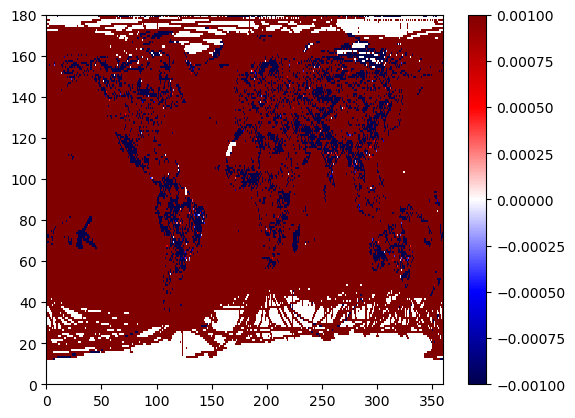


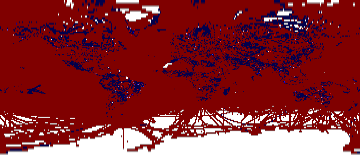

In [6]:
import folium
from folium.plugins import MousePosition
from matplotlib.colors import CenteredNorm, SymLogNorm


lon_step = 1
lat_step = 1

month = 96

millers = ref_data['fossil_imp'][month-12*8,:,:]
ashes = data['fossil_imp_area'][:,:,month]
regions = (ashes.pint.dequantify() - millers) / millers
regions.name = 'delta (umol / m^2 / s)' 
regions = regions.to_numpy()
x = plt.pcolormesh(regions, cmap='seismic', norm=CenteredNorm(halfrange=.001))
plt.colorbar()
plt.show() # to generate color data

m = folium.Map([43, -100], zoom_start=4, crs='EPSG3857')  # crs='EPSG4326'
colors = np.flip(x.get_facecolor().reshape((180,360,4)), axis=0)[10:-10, :]


folium.raster_layers.ImageOverlay(
    image=colors,
    bounds=[[-80, -180], [80, 180]],
    #colormap=x.get_facecolor(),
    opacity = 0.6,
    #crs='EPSG4326',
    mercator_project=True,
).add_to(m)

folium.LayerControl().add_to(m)
MousePosition().add_to(m)
m